# Phase 8: Unified adaptation controller

This notebook reads completed immutable artifacts only. Schema-v7 and schema-v8 runs use one predictable $\pi_t$ for both Fisher-summary blending and mixture-weighted EWC. Schema v8 adds adaptive oracle confidence radii. Historical decoupled runs are shown separately and are never pooled with the principal conditions.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

start = Path.cwd().resolve()
candidates = (start, *start.parents)
REPO_ROOT = next((path for path in candidates if (path / 'mnist_experiment' / 'AGENTS.md').is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError('Could not locate the repository root from the current working directory.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.results_analysis import (
    AnalysisArtifactError,
    discover_phase7_runs,
    discover_phase8_controller_runs,
    phase7_coupled_rows,
    phase7_coupled_summaries,
    phase8_controller_rows,
    phase8_controller_summaries,
)

PHASE8_ROOT = REPO_ROOT / 'cache' / 'mnist_experiment' / 'phase8_runs'
PHASE7_ROOT = REPO_ROOT / 'cache' / 'mnist_experiment' / 'phase7_runs'
phase8_runs = discover_phase8_controller_runs(PHASE8_ROOT)
rows = phase8_controller_rows(phase8_runs)
summary = pd.DataFrame(phase8_controller_summaries(rows))
flat = pd.json_normalize(rows, sep='_')


## Run inventory

In [2]:
inventory = pd.DataFrame([
    {
        'run_id': run.run_id,
        'replica': run.config.replica_id,
        'policy': run.metrics['policy'],
        'metric_schema': run.metrics['phase8_metric_schema_version'],
        'steps': len(run.p_values),
        'samples_per_step': run.config.data.samples_per_step,
        'reference_sample_size': run.config.reference.sample_size,
        'oracle_fit_sample_size': run.config.reference.calibration_steps * run.config.reference.calibration_batch_size,
        'oracle_path_hash': run.metrics['oracle_path_hash'],
    }
    for run in phase8_runs
])
display(inventory)
display(summary)


,run_id,replica,policy,steps,samples_per_step,reference_sample_size,oracle_fit_sample_size,oracle_path_hash
0,mnist_lfu_phase8_controller_smoke__replica-000...,replica-0000,optimal_plugin,3,2,16,8,1ca4fd5bcf931cd7d480db54ce9c1a94ebe29c4560fcbb...
1,mnist_lfu_phase8_fixed_compatibility_smoke__re...,replica-0000,fixed_unified,3,2,16,8,1ca4fd5bcf931cd7d480db54ce9c1a94ebe29c4560fcbb...


,run_id,policy,method,mean_pi,lower_bound_frequency,upper_bound_frequency,mean_fisher_error,mean_trace_relative_error,final_balanced_accuracy,final_parameter_squared_error_to_oracle
0,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,0.05,1.0,0.0,1.055648,1.0,0.1,0.000931
1,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,0.05,1.0,0.0,1.022017,1.0,0.1,0.000932
2,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,low_rank_diagonal_r4,0.05,1.0,0.0,1.067277,1.0,0.1,0.000930
3,mnist_lfu_phase8_fixed_compatibility_smoke__re...,fixed_unified,dense_ridge_full,0.50,0.0,0.0,0.605017,1.0,0.1,0.000934
4,mnist_lfu_phase8_fixed_compatibility_smoke__re...,fixed_unified,diagonal_ridge_full,0.50,0.0,0.0,0.777650,1.0,0.1,0.000934
5,mnist_lfu_phase8_fixed_compatibility_smoke__re...,fixed_unified,low_rank_diagonal_r4,0.50,0.0,0.0,0.674632,1.0,0.1,0.000934


## Unified versus historical fixed weights

The schema-v7 fixed condition uses $\pi=0.5$ in both recursions. The historical schema-v6 condition uses EWC $\pi=0.5$ and an independent Fisher gain $\alpha=0.25$; it is retained only as a compatibility diagnostic.

In [3]:
compatibility = []
fixed_unified = summary[summary['policy'] == 'fixed_unified'].copy()
for _, row in fixed_unified.iterrows():
    compatibility.append({
        'paradigm': 'schema-v7 unified pi=0.5',
        'method': row['method'],
        'mean_fisher_error': row['mean_fisher_error'],
        'final_balanced_accuracy': row['final_balanced_accuracy'],
    })
try:
    _, phase7_coupled = discover_phase7_runs(PHASE7_ROOT)
    legacy_runs = [
        run for run in phase7_coupled
        if run.config.controller.fixed_pi == 0.5
        and run.config.estimator.ema_gain == 0.25
        and run.config.data.num_p_steps == 3
        and run.config.data.samples_per_step == 2
    ]
    legacy_summary = phase7_coupled_summaries(phase7_coupled_rows(legacy_runs))
    for row in legacy_summary:
        compatibility.append({
            'paradigm': 'schema-v6 decoupled pi=0.5, alpha=0.25',
            'method': row['method'],
            'mean_fisher_error': row['mean_fisher_error'],
            'final_balanced_accuracy': row['final_balanced_accuracy'],
        })
except AnalysisArtifactError as error:
    display(Markdown(f'Historical compatibility artifacts unavailable: `{error}`'))
display(pd.DataFrame(compatibility))


,paradigm,method,mean_fisher_error,final_balanced_accuracy
0,schema-v7 unified pi=0.5,dense_ridge_full,0.605017,0.1
1,schema-v7 unified pi=0.5,diagonal_ridge_full,0.777650,0.1
2,schema-v7 unified pi=0.5,low_rank_diagonal_r4,0.674632,0.1
3,"schema-v6 decoupled pi=0.5, alpha=0.25",dense_ridge_full,0.809569,0.1
4,"schema-v6 decoupled pi=0.5, alpha=0.25",diagonal_ridge_full,0.876700,0.1
5,"schema-v6 decoupled pi=0.5, alpha=0.25",low_rank_diagonal_r4,0.852399,0.1


## Controller trajectories

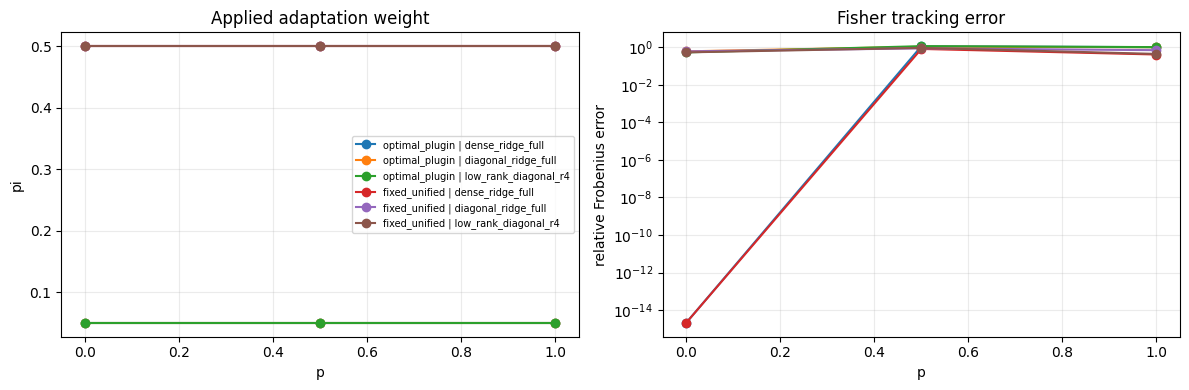

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (run_id, method), group in flat.groupby(['run_id', 'method']):
    ordered = group.sort_values('p')
    label = f"{ordered['policy'].iloc[0]} | {method}"
    axes[0].plot(ordered['p'], ordered['controller_applied_pi'], marker='o', label=label)
    axes[1].plot(ordered['p'], ordered['relative_frobenius_error'], marker='o', label=label)
axes[0].set(title='Applied adaptation weight', xlabel='p', ylabel='pi')
axes[1].set(title='Fisher tracking error', xlabel='p', ylabel='relative Frobenius error')
for axis in axes:
    axis.grid(alpha=0.25)
axes[1].set_yscale('log')
axes[0].legend(fontsize=7)
plt.tight_layout()


## Assumption checks

These checks are part of the controller estimand, not optional numerical decoration. A smoke run establishes software behavior only; controller conclusions require a converged high-sample optimum path, covariance calibration, a stable trace moment, locally centered residuals, and multiple paired replicas.

In [5]:
oracle_fit_rows = []
displacement_rows = []
fisher_convergence_rows = []
for run in phase8_runs:
    checks = run.metrics['oracle_path_checks']
    source = checks.get('independent_fits') or checks['optimization']
    for row in source:
        oracle_fit_rows.append({
            'run_id': run.run_id,
            'policy': run.metrics['policy'],
            **row,
        })
    for row in checks.get('displacement_convergence', []):
        displacement_rows.append({'run_id': run.run_id, 'policy': run.metrics['policy'], **row})
    for row in run.metrics.get('references', []):
        convergence = row.get('convergence')
        if convergence is not None:
            fisher_convergence_rows.append({'run_id': run.run_id, **row, **{f'convergence_{key}': value for key, value in convergence.items()}})
oracle_fit = pd.DataFrame(oracle_fit_rows)
fit_columns = [
    'run_id', 'policy', 'fit_index', 'step', 'p', 'sample_size',
    'last_loss', 'final_minibatch_gradient_norm',
    'training_validation_unique_overlap_fraction',
]
display(oracle_fit[[column for column in fit_columns if column in oracle_fit.columns]])
displacement_convergence = pd.DataFrame(displacement_rows)
if not displacement_convergence.empty:
    display(displacement_convergence[[
        'run_id', 'policy', 'step', 'p', 'estimand', 'count',
        'confidence_radius', 'stopping_threshold', 'converged',
        'fit_count_at_decision', 'lag_one_hilbert_correlation',
    ]])
fisher_convergence = pd.DataFrame(fisher_convergence_rows)
if not fisher_convergence.empty:
    display(fisher_convergence[[
        'run_id', 'method', 'step', 'p', 'sample_count',
        'convergence_count', 'convergence_confidence_radius',
        'convergence_stopping_threshold', 'convergence_converged',
        'convergence_lag_one_hilbert_correlation',
    ]])
gate_failed = (
    (not displacement_convergence.empty and not displacement_convergence['converged'].all())
    or (not fisher_convergence.empty and not fisher_convergence['convergence_converged'].all())
    or ('sample_size' in oracle_fit and (oracle_fit['sample_size'] < 1000).any())
)
if gate_failed:
    display(Markdown('**Scientific gate not met:** at least one oracle estimate hit its budget before satisfying the configured confidence radius, or remains a tiny smoke fit. Controller comparisons are diagnostic only.'))

modern = flat[flat['metric_schema'] >= 3].copy()
check_columns = [
    'run_id', 'policy', 'method', 'step', 'p',
    'controller_applied_pi', 'controller_lower_bound_active',
    'controller_upper_bound_active', 'trend_oracle_norm_error',
    'trend_oracle_cosine', 'controller_trace_estimate',
    'controller_oracle_trace_estimate',
    'trace_relative_error_to_oracle_residual',
    'parameter_squared_error_to_oracle', 'same_pi_consumed',
]
display(modern[check_columns])


,run_id,policy,step,p,sample_size,first_loss,last_loss,final_minibatch_gradient_norm
0,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,0,0.0,8,2.400929,2.331656,0.435074
1,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,1,0.5,8,2.372963,2.328063,0.779595
2,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,2,1.0,8,2.387788,2.377932,1.023045
3,mnist_lfu_phase8_fixed_compatibility_smoke__re...,fixed_unified,0,0.0,8,2.400929,2.331656,0.435074
4,mnist_lfu_phase8_fixed_compatibility_smoke__re...,fixed_unified,1,0.5,8,2.372963,2.328063,0.779595
5,mnist_lfu_phase8_fixed_compatibility_smoke__re...,fixed_unified,2,1.0,8,2.387788,2.377932,1.023045


**Scientific gate not met:** at least one reference optimum is a tiny, visibly unconverged smoke fit. Oracle-policy and trace comparisons are diagnostic only.

,run_id,policy,method,step,p,controller_applied_pi,controller_lower_bound_active,controller_upper_bound_active,trend_oracle_norm_error,trend_oracle_cosine,controller_trace_estimate,oracle_inverse_trace,trace_relative_error_to_oracle,parameter_squared_error_to_oracle,same_pi_consumed
0,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,0,0.0,0.05,True,False,0.015108,NaN,0.000000,215896.290960,1.000000,0.000052,True
1,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,1,0.5,0.05,True,False,0.024307,-0.125278,0.135153,171502.840701,0.999999,0.000500,True
2,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,2,1.0,0.05,True,False,0.011189,NaN,0.271017,776923.426435,1.000000,0.000931,True
3,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,0,0.0,0.05,True,False,0.015108,NaN,0.000000,215896.290960,1.000000,0.000052,True
4,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,1,0.5,0.05,True,False,0.024318,-0.124344,0.136052,171502.840701,0.999999,0.000501,True
5,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,2,1.0,0.05,True,False,0.011197,NaN,0.271654,776923.426435,1.000000,0.000932,True
6,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,low_rank_diagonal_r4,0,0.0,0.05,True,False,0.015108,NaN,0.000000,215896.290960,1.000000,0.000052,True
7,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,low_rank_diagonal_r4,1,0.5,0.05,True,False,0.024310,-0.124303,0.135690,171502.840701,0.999999,0.000501,True
8,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,low_rank_diagonal_r4,2,1.0,0.05,True,False,0.011194,NaN,0.271737,776923.426435,1.000000,0.000930,True
9,mnist_lfu_phase8_fixed_compatibility_smoke__re...,fixed_unified,dense_ridge_full,0,0.0,0.50,False,False,0.015108,NaN,0.000000,215896.290960,1.000000,0.000052,True


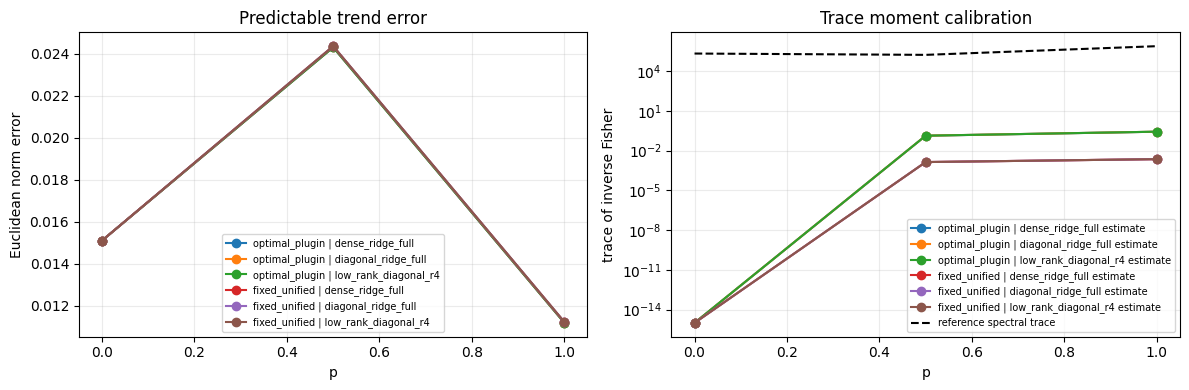

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (run_id, method), group in modern.groupby(['run_id', 'method']):
    ordered = group.sort_values('p')
    label = f"{ordered['policy'].iloc[0]} | {method}"
    axes[0].plot(ordered['p'], ordered['trend_oracle_norm_error'], marker='o', label=label)
    axes[1].plot(ordered['p'], ordered['controller_trace_estimate'].clip(lower=1e-15), marker='o', label=f'{label} plug-in trend')
    axes[1].plot(ordered['p'], ordered['controller_oracle_trace_estimate'].clip(lower=1e-15), linestyle='--', label=f'{label} oracle trend')
axes[0].set(title='Predictable trend error', xlabel='p', ylabel='Euclidean norm error')
axes[1].set(title='Trace moment calibration', xlabel='p', ylabel='trace of inverse Fisher')
axes[1].set_yscale('log')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=7)
plt.tight_layout()


## Curvature and residual diagnostics

In [7]:
turning_rows = []
for run in phase8_runs:
    for row in run.metrics['oracle_path_checks']['turning']:
        turning_rows.append({'run_id': run.run_id, **row})
display(pd.DataFrame(turning_rows))
dependence_rows = []
for run in phase8_runs:
    for method, diagnostics in run.metrics.get('residual_dependence', {}).items():
        dependence_rows.append({'run_id': run.run_id, 'policy': run.metrics['policy'], 'method': method, **diagnostics})
if dependence_rows:
    display(pd.DataFrame(dependence_rows).drop(columns=['plugin_half_life_windows', 'oracle_half_life_windows']))

residual_columns = [
    'run_id', 'method', 'step', 'p', 'acceptance_gain',
    'acceptance_residual_norm', 'acceptance_scale_observation',
    'acceptance_residual_to_scale_ratio',
    'acceptance_oracle_residual_norm',
    'acceptance_oracle_residual_to_scale_ratio',
]
available = [column for column in residual_columns if column in flat.columns]
display(flat[available].dropna(subset=['acceptance_residual_norm'] if 'acceptance_residual_norm' in available else None))


,run_id,angle_radians,cosine,second_difference_norm,step
0,mnist_lfu_phase8_controller_smoke__replica-000...,0.213484,0.977299,0.006532,1
1,mnist_lfu_phase8_fixed_compatibility_smoke__re...,0.213484,0.977299,0.006532,1


,run_id,method,step,p,acceptance_gain,acceptance_residual_norm,acceptance_scale_observation,acceptance_residual_to_scale_ratio
0,mnist_lfu_phase8_controller_smoke__replica-000...,dense_ridge_full,0,0.0,0.823223,0.013132,0.001276,0.135153
1,mnist_lfu_phase8_controller_smoke__replica-000...,dense_ridge_full,1,0.5,0.823223,0.019407,0.001277,0.295024
3,mnist_lfu_phase8_controller_smoke__replica-000...,diagonal_ridge_full,0,0.0,0.823223,0.013176,0.001276,0.136052
4,mnist_lfu_phase8_controller_smoke__replica-000...,diagonal_ridge_full,1,0.5,0.823223,0.019426,0.001277,0.295614
6,mnist_lfu_phase8_controller_smoke__replica-000...,low_rank_diagonal_r4,0,0.0,0.823223,0.013159,0.001276,0.135690
7,mnist_lfu_phase8_controller_smoke__replica-000...,low_rank_diagonal_r4,1,0.5,0.823223,0.019432,0.001277,0.295776
9,mnist_lfu_phase8_fixed_compatibility_smoke__re...,dense_ridge_full,0,0.0,0.823223,0.013289,0.127604,0.001384
10,mnist_lfu_phase8_fixed_compatibility_smoke__re...,dense_ridge_full,1,0.5,0.823223,0.019510,0.156901,0.002426
12,mnist_lfu_phase8_fixed_compatibility_smoke__re...,diagonal_ridge_full,0,0.0,0.823223,0.013291,0.127604,0.001384
13,mnist_lfu_phase8_fixed_compatibility_smoke__re...,diagonal_ridge_full,1,0.5,0.823223,0.019517,0.156901,0.002428
